In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.485459,0.064971,0.106464,0.059912,0.040088,0.016991,-0.128772,0.030929,0.088920,-0.225260,...,1.259511,-0.187895,-0.237601,0.332001,0.000000,-0.255811,-0.228027,0.038290,-0.362826,-0.200426
1,0.666232,-0.952446,-1.099567,-0.755402,-0.875769,-0.824341,-0.652457,-0.744926,-0.477418,-0.603339,...,3.566490,3.137073,0.913224,-1.314176,0.000000,2.591499,1.070407,1.827361,1.866886,0.869468
2,0.337179,0.444285,0.660909,0.338093,0.468616,0.259750,0.440538,0.543698,0.630069,0.754279,...,0.000000,0.082981,0.129427,0.390580,0.524263,-0.050487,-0.580607,-0.345359,-0.452526,-0.057457
3,0.695653,-0.718597,-0.979079,-0.709822,-0.930040,-0.881308,-0.331090,-0.564759,-0.457375,-0.522339,...,3.059892,2.449854,0.967575,-1.179161,0.000000,0.280373,1.104438,-0.345359,1.114908,1.522258
4,0.617917,-0.496529,-0.535096,-0.285114,-0.602328,-0.244920,-0.174518,-0.266658,-0.386906,0.069107,...,0.000000,0.190665,0.869189,-1.477904,3.028668,2.691677,1.352218,2.133915,2.946000,3.137491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.105628,-0.004852,-0.358757,-0.360532,-0.402004,-0.263575,-0.567218,-0.358084,-0.246111,-0.455811,...,0.000000,-0.007844,-0.258121,0.163381,0.000000,-0.508000,0.087068,-0.345359,-0.405549,-0.231420
135,0.267171,1.278289,0.793049,0.011834,0.186224,0.312548,0.304548,0.236335,0.478786,0.257736,...,0.401955,0.179343,0.399712,-0.028726,0.000000,0.619505,-0.164891,0.144386,-0.060514,0.645662
136,0.324219,0.748713,0.215283,-0.194798,-0.504568,-0.064017,0.452283,-0.154471,0.051287,0.016210,...,0.000000,-0.577753,-0.765863,0.578039,0.000000,-0.732668,-0.221085,-0.345359,-0.504845,0.294840
137,-0.351598,-0.195069,0.112013,0.237230,0.100387,0.086725,0.028168,0.200249,0.183658,0.069765,...,0.000000,-0.253379,0.106163,-0.097845,0.000000,0.215431,0.189762,-0.008205,-0.032466,0.889136


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

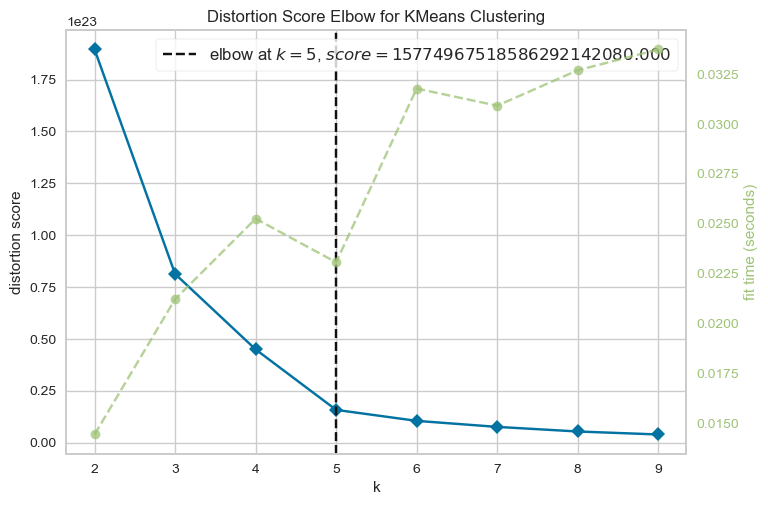

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: glcm_Correlation_d_1_CT_c16, Coefficient: 2.4092994173622992


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: glszm_LargeAreaEmphasis_PET_c04, Coefficient: 0.08115498962564245


...

Cluster 2: Most important feature: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04, Coefficient: 0.0019789270488082635


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: gldm_DependenceNonUniformity_d_1_PET_c04, Coefficient: -0.324505976401546


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: glrlm_ShortRunLowGrayLevelEmphasis_CT_b20, Coefficient: -0.6609340629032369


In [22]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Standardization

In [23]:
# Do the standardization for X_fs_fi
scaler = RobustScaler() 
X_new_std= scaler.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = scaler.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [24]:
X_new

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,0.712490,3.392207e+06,879096.343994,1132.849143,0.000536
1,0.523607,9.996325e+04,26566.901706,177.023053,0.001324
2,0.660634,4.566579e+06,647295.586841,1888.886026,0.000455
3,0.541994,1.798434e+05,40145.962374,211.940366,0.000847
4,0.441477,1.231554e+05,10927.978256,346.285373,0.001143
...,...,...,...,...,...
134,0.680265,7.130061e+05,215024.891557,517.454513,0.001070
135,0.724195,4.579243e+06,338158.975184,1592.627288,0.000553
136,0.607412,2.589594e+06,974304.249507,1021.684898,0.000739
137,0.526798,1.972581e+06,199030.525466,1295.643252,0.000770


In [25]:
X_new_std

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,0.486981,0.345099,0.627985,0.123942,-0.230645
1,-0.817056,-0.349687,-0.249270,-0.517944,0.773474
2,0.128970,0.592935,0.389462,0.631659,-0.333883
3,-0.690116,-0.332829,-0.235297,-0.494495,0.165736
4,-1.384077,-0.344792,-0.265362,-0.404276,0.543393
...,...,...,...,...,...
134,0.264499,-0.220312,-0.055346,-0.289327,0.450506
135,0.567791,0.595608,0.071360,0.432706,-0.209520
136,-0.238476,0.175718,0.725955,0.049289,0.027569
137,-0.795025,0.045505,-0.071804,0.233267,0.068003


In [26]:
MAASTRO_new

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,0.587378,5.846775e+06,1.125054e+06,2486.104657,0.000574
1,0.777112,3.873610e+06,1.948450e+06,1223.288872,0.002657
2,0.734733,3.214991e+06,1.403912e+06,1128.604578,0.000617
3,0.817507,1.459965e+06,4.555744e+05,758.871164,0.005186
4,0.633481,4.406102e+06,8.660429e+05,1924.271323,0.000393
...,...,...,...,...,...
94,0.643053,1.483641e+06,9.500595e+05,803.301749,0.000635
95,0.836867,5.977704e+06,3.718008e+06,1121.977787,0.003568
96,0.614573,1.178081e+07,2.726200e+06,2157.170772,0.000344
97,0.719432,6.169522e+06,2.138315e+06,1866.857748,0.000467


In [27]:
MAASTRO_new_std

,glcm_Correlation_d_1_CT_c16,glszm_LargeAreaEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_ShortRunLowGrayLevelEmphasis_CT_b20
0,-0.376785,0.863105,0.881077,1.032722,-0.182714
1,0.933124,0.446693,1.728353,0.184677,2.473143
2,0.640542,0.307700,1.168022,0.121092,-0.127674
3,1.212005,-0.062676,0.192180,-0.127203,5.697766
4,-0.058496,0.559069,0.614553,0.655422,-0.413366
...,...,...,...,...,...
94,0.007587,-0.057679,0.701007,-0.097366,-0.104615
95,1.345670,0.890735,3.549233,0.116641,3.635137
96,-0.189032,2.115407,2.528660,0.811826,-0.475501
97,0.534907,0.931216,1.923725,0.616866,-0.318530


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:42:19,238] A new study created in memory with name: no-name-5941918d-9789-4c32-ac0e-736c8c25b654
python(81000) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.78125


[I 2024-04-16 00:42:19,424] A new study created in memory with name: no-name-10a5e8ed-1b93-4878-a84e-1efc444e8d68


Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.6244131455399061
[I 2024-04-16 00:42:19,421] Trial 0 finished with value: 0.5926389807855912 and parameters: {}. Best is trial 0 with value: 0.5926389807855912.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5926389807855912], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 19, 301871), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 19, 420820), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5926389807855912


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.27403232615935597
Fold 2 IBS: 0.1851053705996256
Fold 3 IBS: 0.20756780048760695
Fold 4 IBS: 0.19474593140162103
Fold 5 IBS: 0.20373747687206661
[I 2024-04-16 00:42:19,564] Trial 0 finished with value: 0.21303778110405522 and parameters: {}. Best is trial 0 with value: 0.21303778110405522.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21303778110405522], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 19, 440972), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 19, 563931), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21303778110405522


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.593
train_ibs:  0.213


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.545
IBS score: 0.231


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:19,693] A new study created in memory with name: no-name-62f85755-46f4-45d6-a0e2-c52ebf3f3334


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7566964285714286


[I 2024-04-16 00:42:19,779] A new study created in memory with name: no-name-6910b55a-5122-4978-9596-2042aac71d8f


Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6350210970464135
Fold 5 C-index: 0.5610328638497653
[I 2024-04-16 00:42:19,774] Trial 0 finished with value: 0.6445225759836667 and parameters: {}. Best is trial 0 with value: 0.6445225759836667.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6445225759836667], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 19, 712290), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 19, 774760), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6445225759836667


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765137081334
Fold 2 IBS: 0.22157791506947716
Fold 3 IBS: 0.2045359371128086
Fold 4 IBS: 0.22473735434311348
Fold 5 IBS: 0.2181243168929564
[I 2024-04-16 00:42:19,869] Trial 0 finished with value: 0.21659040742529778 and parameters: {}. Best is trial 0 with value: 0.21659040742529778.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659040742529778], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 19, 796083), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 19, 869565), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659040742529778


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.645
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.599


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:19,946] A new study created in memory with name: no-name-0422dd56-6009-4dd0-a293-7711cebebbbd


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.45588235294117646


[I 2024-04-16 00:42:20,194] A new study created in memory with name: no-name-088274af-cf36-4bcf-a4f2-2ff6473a25ad


Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 00:42:20,191] Trial 0 finished with value: 0.5914424074059192 and parameters: {}. Best is trial 0 with value: 0.5914424074059192.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5914424074059192], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 19, 962149), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 20, 191841), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5914424074059192


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26928464615444214
Fold 2 IBS: 0.1870280726175059
Fold 3 IBS: 0.2045849929710722
Fold 4 IBS: 0.19451615280194193
Fold 5 IBS: 0.20873688662466333
[I 2024-04-16 00:42:20,420] Trial 0 finished with value: 0.21283015023392507 and parameters: {}. Best is trial 0 with value: 0.21283015023392507.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21283015023392507], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 20, 208905), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 20, 420783), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21283015023392507


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.591
train_ibs:  0.213


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.55


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.227


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:20,559] A new study created in memory with name: no-name-7d68a7bc-b0e7-4d22-9599-46355b7f2484


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 00:42:20,810] Trial 0 finished with value: 0.5923352645487764 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5923352645487764.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-16 00:42:21,029] Trial 1 finished with value: 0.5942009635828918 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5942009635828918.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-16 00:42:21,252] Trial 2 finished with value: 0.5942009635828918 and parameters: {'l1_ratio': 0.22692876841884668

Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5868544600938967
[I 2024-04-16 00:42:25,683] Trial 24 finished with value: 0.5932619964467415 and parameters: {'l1_ratio': 0.21736087814603194}. Best is trial 23 with value: 0.6360220354369726.
Fold 1 C-index: 0.5281385281385281
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5821596244131455
[I 2024-04-16 00:42:25,932] Trial 25 finished with value: 0.5950350231990558 and parameters: {'l1_ratio': 0.08433745410018247}. Best is trial 23 with value: 0.6360220354369726.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.46568627450980393
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5868544600938967
[I 2024-04-16 00:42:26,158] Trial 26 finished with value: 0.5932619964467415 and parameters: {'l1_ratio': 0.16298478170714284}. Best is trial 23 with val

Fold 1 C-index: 0.5238095238095238
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.5907172995780591
Fold 5 C-index: 0.5915492957746479
[I 2024-04-16 00:42:30,522] Trial 48 finished with value: 0.5960471566055554 and parameters: {'l1_ratio': 0.09764964458649958}. Best is trial 31 with value: 0.6435337725261745.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 00:42:30,725] Trial 49 finished with value: 0.5923352645487764 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 31 with value: 0.6435337725261745.
Fold 1 C-index: 0.5194805194805194
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.45588235294117646
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 00:42:30,925] Trial 50 finished with value: 0.5923352645487764 and parameters: {'l1_ratio': 0.6064718647459

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.2686085882055751
Fold 2 IBS: 0.18740288120376775
Fold 3 IBS: 0.20452846724023452
Fold 4 IBS: 0.1945364168533417
Fold 5 IBS: 0.20875328720278358
[I 2024-04-16 00:42:39,549] Trial 0 finished with value: 0.21276592814114054 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.21276592814114054.
Fold 1 IBS: 0.2699588317656644
Fold 2 IBS: 0.18727438268230162
Fold 3 IBS: 0.20408802638144571
Fold 4 IBS: 0.19458777351109227
Fold 5 IBS: 0.2087267616938552
[I 2024-04-16 00:42:39,766] Trial 1 finished with value: 0.21292715520687183 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.21276592814114054.
Fold 1 IBS: 0.27006720516455507
Fold 2 IBS: 0.18742387725534548
Fold 3 IBS: 0.20406910128433092
Fold 4 IBS: 0.19458474053702599
Fold 5 IBS: 0.20876989859739162
[I 2024-04-16 00:42:39,983] Trial 2 finished with value: 0.21298296456772983 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.2127659281411

Fold 1 IBS: 0.2693358434044883
Fold 2 IBS: 0.1870799744826135
Fold 3 IBS: 0.20468932469657636
Fold 4 IBS: 0.19453112174059148
Fold 5 IBS: 0.20875755980236205
[I 2024-04-16 00:42:45,070] Trial 25 finished with value: 0.21287876482532636 and parameters: {'l1_ratio': 0.6311891505571636}. Best is trial 0 with value: 0.21276592814114054.
Fold 1 IBS: 0.2618628965050943
Fold 2 IBS: 0.19148627635898408
Fold 3 IBS: 0.19835502464654703
Fold 4 IBS: 0.20752606890217554
Fold 5 IBS: 0.2115576789126545
[I 2024-04-16 00:42:45,291] Trial 26 finished with value: 0.21415758906509108 and parameters: {'l1_ratio': 0.015423757551295547}. Best is trial 0 with value: 0.21276592814114054.
Fold 1 IBS: 0.26902191390675334
Fold 2 IBS: 0.18740416983441296
Fold 3 IBS: 0.2045266777377534
Fold 4 IBS: 0.19453622846178692
Fold 5 IBS: 0.20875340705131068
[I 2024-04-16 00:42:45,515] Trial 27 finished with value: 0.21284847939840343 and parameters: {'l1_ratio': 0.6942928064214194}. Best is trial 0 with value: 0.21276592814

Fold 2 IBS: 0.1888199555241491
Fold 3 IBS: 0.20129896930382077
Fold 4 IBS: 0.20609805833599973
Fold 5 IBS: 0.2089213954001119
[I 2024-04-16 00:42:50,326] Trial 50 finished with value: 0.21454496224217304 and parameters: {'l1_ratio': 0.04987669111109051}. Best is trial 45 with value: 0.20509014703105938.
Fold 1 IBS: 0.26956903172635477
Fold 2 IBS: 0.18818914229559983
Fold 3 IBS: 0.2025315945001037
Fold 4 IBS: 0.19461526565798853
Fold 5 IBS: 0.20919181620394484
[I 2024-04-16 00:42:50,570] Trial 51 finished with value: 0.21281937007679833 and parameters: {'l1_ratio': 0.09368746777608235}. Best is trial 45 with value: 0.20509014703105938.
Fold 1 IBS: 0.26661542058614834
Fold 2 IBS: 0.18943207440069768
Fold 3 IBS: 0.20047747175849467
Fold 4 IBS: 0.20652262319770925
Fold 5 IBS: 0.20949955093843445
[I 2024-04-16 00:42:50,786] Trial 52 finished with value: 0.21450942817629692 and parameters: {'l1_ratio': 0.03636331413251584}. Best is trial 45 with value: 0.20509014703105938.
Fold 1 IBS: 0.2701

Fold 1 IBS: 0.21385350966735228
Fold 2 IBS: 0.19273171000679346
Fold 3 IBS: 0.19766097207566338
Fold 4 IBS: 0.2078414765414819
Fold 5 IBS: 0.2119404449469532
[I 2024-04-16 00:42:57,015] Trial 76 finished with value: 0.20480562264764882 and parameters: {'l1_ratio': 0.010690834518691551}. Best is trial 75 with value: 0.20452436920967165.
Fold 1 IBS: 0.2631922681959122
Fold 2 IBS: 0.1910486998340148
Fold 3 IBS: 0.19897252379735653
Fold 4 IBS: 0.2072443158119121
Fold 5 IBS: 0.21086229357677047
[I 2024-04-16 00:42:57,226] Trial 77 finished with value: 0.21426402024319322 and parameters: {'l1_ratio': 0.020248149705777405}. Best is trial 75 with value: 0.20452436920967165.
Fold 1 IBS: 0.21395913817887344
Fold 2 IBS: 0.22157395025920865
Fold 3 IBS: 0.20451390439776024
Fold 4 IBS: 0.22315002340437393
Fold 5 IBS: 0.2181277755436232
[I 2024-04-16 00:42:57,287] Trial 78 finished with value: 0.2162649583567679 and parameters: {'l1_ratio': 0.00022989146138922834}. Best is trial 75 with value: 0.2045

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.644
train_ibs:  0.205


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.0001256264476044225)

test_cindex : 0.597


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.014683476227501064)

test_ibs:  0.221


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:43:02,313] A new study created in memory with name: no-name-0e639b12-0bac-4f32-88ed-6e0d3f74a4b9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5064935064935064
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.6397058823529411
Fold 4 C-index: 0.5822784810126582
Fold 5 C-index: 0.5938967136150235
[I 2024-04-16 00:43:03,653] Trial 0 finished with value: 0.615367773837683 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.615367773837683.
Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.5736607142857143
Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.6118143459915611
Fold 5 C-index: 0.5774647887323944
[I 2024-04-16 00:43:04,612] Trial 1 finished with value: 0.5954196479277297 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:43:19,804] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 95, 'oob_score': True, 'max_samples': 0.827141133035673, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.4285489292377008, 'warm_start': True}. Best is trial 14 with value: 0.6398019120896548.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:43:19,890] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 17, 'max_depth': 5, 'n_estimators': 7, 'oob_score': True, 'max_samples': 0.48750680461992774, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.36880787712230256, 'warm_start': True}. Best is trial 14 with value: 0.6398019120896548.
Fold 1 C-index: 0.5476190476190477
Fo

Fold 3 C-index: 0.7573529411764706
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.7464788732394366
[I 2024-04-16 00:43:29,391] Trial 31 finished with value: 0.7332606091432504 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 9, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 500, 'oob_score': True, 'max_samples': 0.7586726862510783, 'max_features': None, 'min_weight_fraction_leaf': 0.10075714732447466, 'warm_start': True}. Best is trial 29 with value: 0.7475453906055526.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8660714285714286
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.7793427230046949
[I 2024-04-16 00:43:30,851] Trial 32 finished with value: 0.7526570471135666 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 477, 'oob_score': True, 'max_samples': 0.7515351052697278, 'max_features': None, 'min_weight_fraction_leaf': 0.08748806099321796, 

...

Fold 2 IBS: 0.221063439289212
Fold 3 IBS: 0.20476084655951457
Fold 4 IBS: 0.22455655421641582
Fold 5 IBS: 0.2186039328557067
[I 2024-04-16 00:45:03,742] Trial 33 finished with value: 0.21659361140813624 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.7992168963364227, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.4514697895015368}. Best is trial 19 with value: 0.20579011692573804.
Fold 1 IBS: 0.2139720782758313
Fold 2 IBS: 0.22144108998337708
Fold 3 IBS: 0.20447370531640058
Fold 4 IBS: 0.22469609097514986
Fold 5 IBS: 0.21791962542900598
[I 2024-04-16 00:45:04,185] Trial 34 finished with value: 0.21650051799595293 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 15, 'max_depth': 3, 'n_estimators': 61, 'oob_score': True, 'max_samples': 0.5105310449294201, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3203304167522589}. Best is trial

Fold 1 IBS: 0.21629442673139357
Fold 2 IBS: 0.18088656029131617
Fold 3 IBS: 0.19441085672674183
Fold 4 IBS: 0.2197540441698311
Fold 5 IBS: 0.2209903237182853
[I 2024-04-16 00:45:18,451] Trial 49 finished with value: 0.20646724232751362 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 16, 'n_estimators': 139, 'oob_score': True, 'max_samples': 0.7346491917439176, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.25981797560073444}. Best is trial 48 with value: 0.20571112495567534.
Fold 1 IBS: 0.21575444090442525
Fold 2 IBS: 0.18142726062110287
Fold 3 IBS: 0.19468038436915872
Fold 4 IBS: 0.21922722596059563
Fold 5 IBS: 0.22115702790936237
[I 2024-04-16 00:45:20,612] Trial 50 finished with value: 0.20644926795292898 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 220, 'oob_score': True, 'max_samples': 0.724562307229254, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 1 IBS: 0.2140144474495841
Fold 2 IBS: 0.22181886593997027
Fold 3 IBS: 0.20483793084945423
Fold 4 IBS: 0.22488234119966374
Fold 5 IBS: 0.21842924528246183
[I 2024-04-16 00:45:47,319] Trial 65 finished with value: 0.21679656614422682 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 5, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 158, 'oob_score': False, 'max_samples': 0.5882723494673029, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.36627818665076384}. Best is trial 48 with value: 0.20571112495567534.
Fold 1 IBS: 0.21723447834397253
Fold 2 IBS: 0.17971601945605448
Fold 3 IBS: 0.1947241835406929
Fold 4 IBS: 0.21872748066861053
Fold 5 IBS: 0.22068551855955065
[I 2024-04-16 00:45:49,202] Trial 66 finished with value: 0.20621753611377622 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 6, 'min_samples_leaf': 7, 'max_depth': 17, 'n_estimators': 127, 'oob_score': True, 'max_samples': 0.6763611194745864, 'max_features': 'sqrt', 'min_weight_fraction_l

Fold 1 IBS: 0.21402553409326966
Fold 2 IBS: 0.18121327486773217
Fold 3 IBS: 0.19643695411316475
Fold 4 IBS: 0.2188691568532567
Fold 5 IBS: 0.21911032137230857
[I 2024-04-16 00:46:03,131] Trial 81 finished with value: 0.20593104825994635 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 11, 'min_samples_leaf': 10, 'max_depth': 17, 'n_estimators': 91, 'oob_score': False, 'max_samples': 0.7784763388289013, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.30048645282239506}. Best is trial 48 with value: 0.20571112495567534.
Fold 1 IBS: 0.21433292302379162
Fold 2 IBS: 0.1819067262189654
Fold 3 IBS: 0.19655885931215208
Fold 4 IBS: 0.21913035338626585
Fold 5 IBS: 0.21882953180947165
[I 2024-04-16 00:46:04,003] Trial 82 finished with value: 0.20615167875012932 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 13, 'min_samples_leaf': 10, 'max_depth': 16, 'n_estimators': 87, 'oob_score': False, 'max_samples': 0.7768559210472288, 'max_features': 'sqrt', 'min_weight_fraction

Fold 5 IBS: 0.21833765645987288
[I 2024-04-16 00:46:23,257] Trial 96 finished with value: 0.20632128127083757 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 17, 'n_estimators': 85, 'oob_score': False, 'max_samples': 0.9665076685881789, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3835259786937849}. Best is trial 92 with value: 0.20458968496244653.
Fold 1 IBS: 0.21323060467921712
Fold 2 IBS: 0.18716550303724294
Fold 3 IBS: 0.19689904431205096
Fold 4 IBS: 0.21976483007772124
Fold 5 IBS: 0.2133712926066197
[I 2024-04-16 00:46:24,621] Trial 97 finished with value: 0.20608625494257043 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 10, 'max_depth': 13, 'n_estimators': 119, 'oob_score': False, 'max_samples': 0.7513539538887252, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3590477358325388}. Best is trial 92 with value: 0.20458968496244653.
Fold 1 IBS: 0.21796263985409997
Fold 2 IBS: 0.1744

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.823
train_ibs:  0.205


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_features='auto', max_leaf_nodes=16,
                     max_samples=0.5846804217708853, min_samples_leaf=1,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.019001979711902286,
                     n_estimators=413, random_state=123, warm_start=True)

test_cindex:  0.602


RandomSurvivalForest(max_depth=15, max_leaf_nodes=9,
                     max_samples=0.7990030276222911, min_samples_leaf=11,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.3646451011163488,
                     n_estimators=11, random_state=123)

test_ibs:  0.214


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:46:29,575] A new study created in memory with name: no-name-9505e65a-cd68-4bda-836e-65b29a200e8b


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5821596244131455
[I 2024-04-16 00:46:31,057] Trial 0 finished with value: 0.6556136850435405 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6556136850435405.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:46:34,001] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7879464285714286
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.6181434599156118
Fold 5 C-index: 0.5704225352112676
[I 2024-04-16 00:47:18,838] Trial 16 finished with value: 0.630634799483741 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.6613752189801188.
Fold 1 C-index: 0.538961038961039
Fold 2 C-index: 0.7142857142857143
Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.6012658227848101
Fold 5 C-index: 0.5352112676056338
[I 2024-04-16 00:47:20,498] Trial 17 finished with value: 0.6073565334333217 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_feature

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.6431924882629108
[I 2024-04-16 00:47:53,715] Trial 31 finished with value: 0.6768747829607215 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 458, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9352764128747875, 'min_weight_fraction_leaf': 0.07589392630375186}. Best is trial 30 with value: 0.6768747829607215.
Fold 1 C-index: 0.5627705627705628
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.6764705882352942
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 00:47:56,571] Trial 32 finished with value: 0.6837227070198897 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 434, 'oob_score': False, 'warm_start': True, 'max_features': 

...

Fold 1 IBS: 0.21453627305020168
Fold 2 IBS: 0.2192704584296414
Fold 3 IBS: 0.2007818292403716
Fold 4 IBS: 0.21609516342367474
Fold 5 IBS: 0.2146059264718902
[I 2024-04-16 00:51:14,510] Trial 30 finished with value: 0.21305793012315594 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 62, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.5897285086805036, 'min_weight_fraction_leaf': 0.10310563679536389}. Best is trial 23 with value: 0.20946042040490367.
Fold 1 IBS: 0.2130640147788643
Fold 2 IBS: 0.21007937232732365
Fold 3 IBS: 0.19724763489171343
Fold 4 IBS: 0.20899693831772778
Fold 5 IBS: 0.21605559871689853
[I 2024-04-16 00:51:17,607] Trial 31 finished with value: 0.20908871180650554 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 317, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.

Fold 1 IBS: 0.21620665392339558
Fold 2 IBS: 0.2100863691449903
Fold 3 IBS: 0.19766446154097644
Fold 4 IBS: 0.20714105244297082
Fold 5 IBS: 0.2155958045466163
[I 2024-04-16 00:51:52,406] Trial 45 finished with value: 0.20933886831978993 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 348, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8000155376408778, 'min_weight_fraction_leaf': 0.0253449665288179}. Best is trial 38 with value: 0.20776948232011377.
Fold 1 IBS: 0.21614268468905024
Fold 2 IBS: 0.21044270460961462
Fold 3 IBS: 0.19749319338809745
Fold 4 IBS: 0.20690133290509935
Fold 5 IBS: 0.21558920279688795
[I 2024-04-16 00:51:55,160] Trial 46 finished with value: 0.20931382367774992 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 339, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7

Fold 1 IBS: 0.21552680767650967
Fold 2 IBS: 0.20799965563912434
Fold 3 IBS: 0.19358374848812715
Fold 4 IBS: 0.20235960673622197
Fold 5 IBS: 0.2165405306377285
[I 2024-04-16 00:52:24,058] Trial 60 finished with value: 0.20720206983554235 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 249, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.616241916226178, 'min_weight_fraction_leaf': 0.003967184995733371}. Best is trial 60 with value: 0.20720206983554235.
Fold 1 IBS: 0.215356274212404
Fold 2 IBS: 0.21703705292238087
Fold 3 IBS: 0.20201805399883638
Fold 4 IBS: 0.2198696091912128
Fold 5 IBS: 0.21685899177574633
[I 2024-04-16 00:52:25,723] Trial 61 finished with value: 0.21422799642011606 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 9, 'min_samples_leaf': 20, 'max_depth': 11, 'n_estimators': 254, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.61929

Fold 1 IBS: 0.21420195525226784
Fold 2 IBS: 0.2078853874669619
Fold 3 IBS: 0.1940464173845735
Fold 4 IBS: 0.20580594068108726
Fold 5 IBS: 0.21457511302678167
[I 2024-04-16 00:52:42,972] Trial 75 finished with value: 0.20730296276233445 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 271, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.43928953862640563, 'min_weight_fraction_leaf': 0.03697760931061604}. Best is trial 74 with value: 0.20645714689968084.
Fold 1 IBS: 0.21288250368044884
Fold 2 IBS: 0.20958006262595538
Fold 3 IBS: 0.1950134623908453
Fold 4 IBS: 0.20603462896646063
Fold 5 IBS: 0.21561754567550862
[I 2024-04-16 00:52:44,469] Trial 76 finished with value: 0.20782564066784373 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 5, 'n_estimators': 242, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.423375

Fold 1 IBS: 0.21795024016159353
Fold 2 IBS: 0.20971622982466237
Fold 3 IBS: 0.1973544524573259
Fold 4 IBS: 0.20859571633780422
Fold 5 IBS: 0.2159760058600746
[I 2024-04-16 00:53:07,071] Trial 90 finished with value: 0.20991852892829216 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 3, 'n_estimators': 87, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.4689055002580241, 'min_weight_fraction_leaf': 0.07833775534295052}. Best is trial 82 with value: 0.205855862632547.
Fold 1 IBS: 0.21632269716861008
Fold 2 IBS: 0.20540941980088895
Fold 3 IBS: 0.19387411616722822
Fold 4 IBS: 0.20351355449505196
Fold 5 IBS: 0.21672157331146746
[I 2024-04-16 00:53:08,524] Trial 91 finished with value: 0.20716827218864933 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 182, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.591693238

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.753
train_ibs:  0.206


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=12, max_features=None, max_leaf_nodes=14,
                   max_samples=0.9354353438128834, min_samples_split=10,
                   min_weight_fraction_leaf=0.02793704280442395,
                   n_estimators=32, random_state=123, warm_start=True)

C-index score: 0.621


ExtraSurvivalTrees(max_depth=9, max_features=None, max_leaf_nodes=3,
                   max_samples=0.5904597882426209, min_samples_split=5,
                   min_weight_fraction_leaf=0.029830684722728408,
                   n_estimators=177, oob_score=True, random_state=123)

IBS: 0.211


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:53:21,485] A new study created in memory with name: no-name-f5b06b23-55fd-4e61-bc78-c6fe568eae57


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:53:34,301] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:53:44,403] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:57:59,380] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6032911804691731.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:58:29,068] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:02:35,954] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6032911804691731.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:03:33,402] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 02:36:07,282] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.2165277920345167.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 02:36:39,729] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsam

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 02:40:34,377] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.2165277920345167.
Fold 1 IBS: 0.2138535431471158
Fold 2 IBS: 0.22149198516337618
Fold 3 IBS: 0.20432610545271634
Fold 4 IBS: 0.22439344323757704
Fold 5 IBS: 0.21810998571682771
[I 2024-04-16 02:40:52,407] Trial 57 finished with value: 0.21643501254352265 and parameters: {'subsample': 0.553868700002313, 'l

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 02:47:34,751] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21593399630112095.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-16 02:48:19,745] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 

Fold 2 IBS: 0.22041668834614597
Fold 3 IBS: 0.20370864945798123
Fold 4 IBS: 0.22389489022695505
Fold 5 IBS: 0.21793821829345564
[I 2024-04-16 02:54:06,669] Trial 78 finished with value: 0.21591272137886564 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.21570658632524845.
Fold 1 IBS: 0.2137961248495413
Fold 2 IBS: 0.22041069087759574
Fold 3 IBS: 0.20375198796321609
Fold 4 IBS: 0.22399625415353744
Fold 5 IBS: 0.21794144852983757
[I 2024-04-16 02:54:22,430] Trial 79 finished with value: 0.21597930127474566 and parameters: {'subsample': 0.33166032751272

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:58:02,806] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5047949630079825, 'learning_rate': 0.07570365267350251, 'dropout_rate': 0.9185384407502093, 'n_estimators': 425, 'criterion': 'squared_error', 'ccp_alpha': 1.43651786790132, 'min_weight_fraction_leaf': 0.37614184555110525, 'max_features': 'log2', 'min_impurity_decrease': 0.0012523843835151739, 'validation_fraction': 0.7198052772212644, 'min_samples_split': 20, 'max_leaf_nodes': 10, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 75 with value: 0.21570658632524845.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:58:44,433] Trial 90 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.449623904707342,

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.616
train_ibs:  0.216


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.08304534706000144,
                                 dropout_rate=0.8003972830508307,
                                 learning_rate=0.06741276323402065, max_depth=2,
                                 max_leaf_nodes=4,
                                 min_impurity_decrease=0.0002469950977072107,
                                 min_samples_leaf=8, min_samples_split=3,
                                 min_weight_fraction_leaf=0.47835629989654377,
                                 n_estimators=296, random_state=123,
                                 subsample=0.49605383018584304,
                                 validation_fraction=0.46406091324791776)

C-index score: 0.567


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009365616677551508,
                                 dropout_rate=0.7826693566389662,
                                 learning_rate=0.08843409287484169, max_depth=4,
                                 max_features='log2', max_leaf_nodes=14,
                                 min_impurity_decrease=0.0008096076350961149,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2812508412156809,
                                 n_estimators=403, random_state=123,
                                 subsample=0.5200735929114648,
                                 validation_fraction=0.7004324115891782)

IBS: 0.221


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 03:03:55,982] A new study created in memory with name: no-name-0800f6ac-b4fa-495b-aa48-2a8d4ec3e83a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5637254901960784
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5868544600938967
[I 2024-04-16 03:03:57,374] Trial 0 finished with value: 0.6179666942061676 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6179666942061676.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5821596244131455
[I 2024-04-16 03:04:09,036] Trial 1 finished with value: 0.6160473349131546 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6179666942061676.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.5637254901960784
Fold 

Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5784313725490197
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.5774647887323944
[I 2024-04-16 03:04:56,653] Trial 19 finished with value: 0.614641682253543 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.99497601792777, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 10 with value: 0.6184196082767051.
Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5490196078431373
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.6103286384976526
[I 2024-04-16 03:04:57,297] Trial 20 finished with value: 0.611814783248102 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.8366344916821274, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 10 with value: 0.6184196082767051.
Fold 1 C-index: 0.5324675324675324
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5637254901960784
Fold 4 C-index: 0.59493670

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.5588235294117647
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5727699530516432
[I 2024-04-16 03:05:37,714] Trial 38 finished with value: 0.6123836863551398 and parameters: {'subsample': 0.6765557595745939, 'dropout_rate': 0.23835904748876566, 'n_estimators': 314, 'learning_rate': 0.06351044805702724}. Best is trial 23 with value: 0.6228001736927125.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.5735294117647058
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.5774647887323944
[I 2024-04-16 03:05:39,204] Trial 39 finished with value: 0.6153709728190211 and parameters: {'subsample': 0.8328204942141013, 'dropout_rate': 0.35009962810023976, 'n_estimators': 126, 'learning_rate': 0.03446657252780899}. Best is trial 23 with value: 0.6228001736927125.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5588235294117647
Fold 4 C-i

...

Fold 2 IBS: 0.21497309039773008
Fold 3 IBS: 0.23197648837470675
Fold 4 IBS: 0.260228281147637
Fold 5 IBS: 0.22973759401514568
[I 2024-04-16 03:10:55,768] Trial 19 finished with value: 0.24765075115666138 and parameters: {'subsample': 0.23213625139224725, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.04061015936667263}. Best is trial 15 with value: 0.20905661044133902.
Fold 1 IBS: 0.2846503841829487
Fold 2 IBS: 0.2246551816036513
Fold 3 IBS: 0.22062590928657722
Fold 4 IBS: 0.25617791451580935
Fold 5 IBS: 0.2290800168501816
[I 2024-04-16 03:10:57,779] Trial 20 finished with value: 0.24303788128783363 and parameters: {'subsample': 0.3923190305501453, 'dropout_rate': 0.30866564063362517, 'n_estimators': 150, 'learning_rate': 0.0817175642960023}. Best is trial 15 with value: 0.20905661044133902.
Fold 1 IBS: 0.22072092595700826
Fold 2 IBS: 0.21523313269439917
Fold 3 IBS: 0.20234398761104114
Fold 4 IBS: 0.19700276196857935
Fold 5 IBS: 0.21627486680618674
[I 2024-

Fold 2 IBS: 0.21613660236159946
Fold 3 IBS: 0.20073384009640202
Fold 4 IBS: 0.1985785805041123
Fold 5 IBS: 0.21618555736162703
[I 2024-04-16 03:11:34,653] Trial 38 finished with value: 0.2096992477896243 and parameters: {'subsample': 0.7863832596919312, 'dropout_rate': 0.4952510091041102, 'n_estimators': 184, 'learning_rate': 0.009639262805202515}. Best is trial 31 with value: 0.20846905736825905.
Fold 1 IBS: 0.2577988059913882
Fold 2 IBS: 0.21419301816363986
Fold 3 IBS: 0.19976016886697537
Fold 4 IBS: 0.21016629881857649
Fold 5 IBS: 0.21772786379006231
[I 2024-04-16 03:11:40,253] Trial 39 finished with value: 0.21992923112612844 and parameters: {'subsample': 0.5346500299053596, 'dropout_rate': 0.38248721317625467, 'n_estimators': 291, 'learning_rate': 0.024902695038791604}. Best is trial 31 with value: 0.20846905736825905.
Fold 1 IBS: 0.23889983833935166
Fold 2 IBS: 0.21229786734673348
Fold 3 IBS: 0.19670182994234262
Fold 4 IBS: 0.19302657580923135
Fold 5 IBS: 0.21510354443815505
[I 2

Fold 1 IBS: 0.2233274046379071
Fold 2 IBS: 0.21292704784895206
Fold 3 IBS: 0.19782411906799177
Fold 4 IBS: 0.19319566206955954
Fold 5 IBS: 0.2150185786291254
[I 2024-04-16 03:12:32,643] Trial 57 finished with value: 0.20845856245070715 and parameters: {'subsample': 0.7996621418293133, 'dropout_rate': 0.14357418980618802, 'n_estimators': 215, 'learning_rate': 0.016094740842945165}. Best is trial 57 with value: 0.20845856245070715.
Fold 1 IBS: 0.21686830524560496
Fold 2 IBS: 0.21706616702689
Fold 3 IBS: 0.20177550781677203
Fold 4 IBS: 0.2005517223039037
Fold 5 IBS: 0.21655364198579347
[I 2024-04-16 03:12:36,693] Trial 58 finished with value: 0.21056306887579282 and parameters: {'subsample': 0.8995542733815092, 'dropout_rate': 0.1693408503265602, 'n_estimators': 215, 'learning_rate': 0.006525158392390441}. Best is trial 57 with value: 0.20845856245070715.
Fold 1 IBS: 0.221892542567278
Fold 2 IBS: 0.21369891928592077
Fold 3 IBS: 0.19891289039098073
Fold 4 IBS: 0.1944915283739136
Fold 5 IBS

Fold 1 IBS: 0.23798041646935986
Fold 2 IBS: 0.2143655004775083
Fold 3 IBS: 0.19720099630618632
Fold 4 IBS: 0.19430294595740202
Fold 5 IBS: 0.2159321802619168
[I 2024-04-16 03:13:31,664] Trial 76 finished with value: 0.21195640789447467 and parameters: {'subsample': 0.5846048361303321, 'dropout_rate': 0.10214269047342033, 'n_estimators': 184, 'learning_rate': 0.03384302973207384}. Best is trial 70 with value: 0.20829687969542277.
Fold 1 IBS: 0.22432693853180466
Fold 2 IBS: 0.21245511594795102
Fold 3 IBS: 0.1977237643143761
Fold 4 IBS: 0.19284678119510099
Fold 5 IBS: 0.21500687089595938
[I 2024-04-16 03:13:33,385] Trial 77 finished with value: 0.20847189417703843 and parameters: {'subsample': 0.7343719182144554, 'dropout_rate': 0.18010563048957345, 'n_estimators': 119, 'learning_rate': 0.03052879296542746}. Best is trial 70 with value: 0.20829687969542277.
Fold 1 IBS: 0.22472966107630163
Fold 2 IBS: 0.2160355150057048
Fold 3 IBS: 0.19678479135666704
Fold 4 IBS: 0.19484692538426568
Fold 5

Fold 1 IBS: 0.21617568407052215
Fold 2 IBS: 0.2136148590875222
Fold 3 IBS: 0.19893328033587063
Fold 4 IBS: 0.19516874029629697
Fold 5 IBS: 0.2153262280371113
[I 2024-04-16 03:13:51,590] Trial 95 finished with value: 0.20784375836546465 and parameters: {'subsample': 0.8354991147243417, 'dropout_rate': 0.10782916223784064, 'n_estimators': 63, 'learning_rate': 0.04423809181222279}. Best is trial 90 with value: 0.20718972753817694.
Fold 1 IBS: 0.21415041593217282
Fold 2 IBS: 0.21839618982865988
Fold 3 IBS: 0.2021907198265308
Fold 4 IBS: 0.20255030369737892
Fold 5 IBS: 0.21705038092379186
[I 2024-04-16 03:13:52,056] Trial 96 finished with value: 0.21086760204170685 and parameters: {'subsample': 0.8304880838324005, 'dropout_rate': 0.10309604837508969, 'n_estimators': 18, 'learning_rate': 0.057425548394441216}. Best is trial 90 with value: 0.20718972753817694.
Fold 1 IBS: 0.21650987547090325
Fold 2 IBS: 0.2141067451874561
Fold 3 IBS: 0.19922309368384505
Fold 4 IBS: 0.1956725632057739
Fold 5 I

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.623
train_ibs:  0.207


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5670501659795346,
                                              learning_rate=0.010496184153284481,
                                              n_estimators=56, random_state=123,
                                              subsample=0.8054496546831427)

C-index score: 0.602


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10184332440552968,
                                              learning_rate=0.04619100145988285,
                                              n_estimators=74, random_state=123,
                                              subsample=0.8218923336919075)

IBS: 0.218


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.823,1.0
ExtraSurvivalTrees,0.753,2.0
CoxRidge,0.645,3.0
CoxElastic,0.644,4.0
ComponentwiseGradientBoosting,0.623,5.0
GradientBoosting,0.616,6.0
CoxPH,0.593,7.0
CoxLasso,0.591,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxElastic,0.205,1.5
Randomsurvivalforest,0.205,1.5
ExtraSurvivalTrees,0.206,3.0
ComponentwiseGradientBoosting,0.207,4.0
CoxPH,0.213,5.5
CoxLasso,0.213,5.5
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.621,1.0
Randomsurvivalforest,0.602,2.5
ComponentwiseGradientBoosting,0.602,2.5
CoxRidge,0.599,4.0
CoxElastic,0.597,5.0
GradientBoosting,0.567,6.0
CoxLasso,0.550,7.0
CoxPH,0.545,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.211,1.0
Randomsurvivalforest,0.214,2.0
ComponentwiseGradientBoosting,0.218,3.0
CoxRidge,0.221,5.0
CoxElastic,0.221,5.0
GradientBoosting,0.221,5.0
CoxLasso,0.227,7.0
CoxPH,0.231,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/robust/cfi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_robust_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-16
